In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from collections import defaultdict
from xgboost import XGBRegressor
import tensorflow
from tensorflow.keras import models, layers
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import mean_squared_error
from scipy.optimize import curve_fit
import numpy as np


Supplementary Data Processing

In [5]:
def processed_holidays_events():
    """
    Returns an embedded dictionary with has_holiday[data][locale] returning True or False

    Returns
    -------
    has_holiday: dict
        The dictionary returning whether theres a holiday on that given day
    """

    holidays_events = pd.read_csv("holidays_events.csv")
    holidays_events = holidays_events[holidays_events["transferred"] == False]
    holidays_events = holidays_events.drop(columns=["description"])

    date_grouped_holidays = holidays_events.groupby("date")

    has_holiday = defaultdict(lambda: defaultdict(lambda: False)) #Defaults to {date: {city: False}}
    for date, grouped_table in date_grouped_holidays:
        if "National" in grouped_table["locale"].unique():
            has_holiday[date] = defaultdict(lambda: True)
            continue
        for city in grouped_table["locale_name"].to_list():
            has_holiday[date][city] = True

    return has_holiday

In [6]:
def process_oil_prices():
    """
    Returns a dictionary with date pointing to oil prices.

    Returns
    -------
    oil_prices: dict
        The dictionary with schema {date : oil_price}
    """
    
    oil_prices = pd.read_csv("oil.csv").set_index("date")
    return oil_prices.to_dict()['dcoilwtico']

In [7]:
def process_stores_table():
    """
    Processes and returns the stores table

    Returns
    -------
    stores: pd.DataFrame 
    """
    
    stores = pd.read_csv("stores.csv")

    stores["type"] = stores.apply(
        lambda row: "Other" if row["type"] not in ["D", "C"] else row["type"], axis=1
    )
    
    stores["cluster"] = stores["cluster"].astype("category")
    stores["type"] = stores["type"].astype("category")

    return stores


Time Series Data Processing

In [8]:
def process_lstm_data(data):
    """
    Processes store price data and groups by store_nbr, family

    Paramters
    ---------
    data: pd.DataFrame
        The dataframe containing the time series data
    
    Returns
    -------
    key_to_df : dict[str: pd.DataFrame]
        dictionary with (store_nbr, family) pointing to the grouped dataframe
    """
    
    grouped_data =  data.groupby(["store_nbr", "family"])
    key_to_df = {}
    for (store_nbr, family), grouped_df in grouped_data:
        grouped_df = grouped_df[["date", "sales"]]
        key_to_df[(store_nbr, family)] = grouped_df
    return key_to_df
    

In [9]:
def create_sequences(data_array, seq_len):
    """ 
    Sequentializes an array and returns the sequnces

    Paramters
    ---------
    data_array: np.array
        The array to sequentialize
    seq_len: int
        The length of each sequnce
    
    Returns 
    -------
    X_seq: np.array
        A 2D array containing the sequences from time t-seq_len to time t-1
    y_seq: np.array
        A 1D array containing the value at time t
    """

    X_seq, y_seq = [], []

    for i in range(len(data_array) - seq_len):
        X_seq.append(data_array[i:i+seq_len])
        y_seq.append(data_array[i+seq_len, 0])
    
    return np.array(X_seq), np.array(y_seq).reshape(-1,1)

In [53]:
def train_lstm_model(grouped_data, seq_len):
    """ 
    Initializes a 1D LSTM model trained on grouped (store_nbr, family) data

    Paramters
    ---------
    grouped_data: pd.DataFrame
        The time series data to train on
    seq_len: int
        The window length to train the model on
    
    Returns
    -------
    model: models.Sequential
        The trained LSTM Model
    val_rmse: float
        The Validation Root Mean Squared Error of this model
    """
    
    # Creating features
    grouped_data["roc"] = grouped_data["sales"].pct_change().fillna(0).replace([np.inf, -np.inf], 0)
    grouped_data['rolling_avg'] = grouped_data['sales'].rolling(window=5, center=False).mean().fillna(0)
    grouped_data['rolling_std'] = grouped_data['sales'].rolling(window=5).std().fillna(0)

    # Create Sequence values
    grouped_data = grouped_data.sort_values("date")
    features = ["sales", "roc", "rolling_avg", "rolling_std"]
    data_array = grouped_data[features].to_numpy()

    X, y = create_sequences(data_array, seq_len)

    # Simple train / test split
    split = int(0.75 * len(X))
    X_train, X_val = X[:split], X[split:]
    y_train, y_val = y[:split], y[split:]

    #Adapting the noramalization layer
    normalizer = layers.Normalization(axis=-1)
    normalizer.adapt(X_train)

    # Initialize the model
    num_features = 4
    hidden_dim = 64

    model = models.Sequential([ 
        layers.Input(shape=(seq_len, num_features)), 
        normalizer,
        layers.LSTM(hidden_dim, dropout=0.2), 
        layers.Dense(1)
    ])

    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.01), 
        loss='mse', 
        metrics=[tensorflow.keras.metrics.RootMeanSquaredError()]
    )   

    # Train the model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=64,
        verbose=0
    )

    # Validate the model
    y_val_pred = model.predict(X_val, verbose=0)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    # Populate the original dataframe
    y_pred = model.predict(X, verbose=0)
    y_pred = [np.nan]*seq_len + y_pred.flatten().tolist()
    populated_df = grouped_data.copy()
    populated_df["lstm_forecast"] = y_pred

    return model, val_rmse, populated_df


In [11]:
def populate_lstm_predictions(grouped_data, lstm_model):
    """
    Runs inference on time series data and returns the inferred values

    Paramters
    ---------
    grouped_data: pd.DataFrame
        The dataframe to populate with the model inferences
    lstm_model: models.Sequential
        The inference model
    
    Returns
    -------
    populated_df: pd.DataFrame
        The populated dataframe
    """

    seq_len = lstm_model.input_shape[1]
    num_features = lstm_model.input_shape[2]
    
    data_array = grouped_data.sort_values("date")["sales"].to_numpy()
    X, _ = create_sequences(data_array, seq_len)

    y_pred = lstm_model.predict(X, verbose=0)

    predictions = [np.nan]*seq_len + y_pred.flatten().tolist()

    populated_df = grouped_data.copy()
    populated_df["lstm_forecast"] = predictions

    return populated_df

In [48]:
def plot_lstm_predictions(data):
    """Plots the LSTM Forecast for that specific (store_nbr, family) pair."""

    dates = data["date"]
    y_true = data["sales"]
    y_pred = data["lstm_forecast"]

    plt.figure(figsize=(12,6))
    plt.plot(dates, y_true, label='Actual', marker='o')
    plt.plot(dates, y_pred, label='Predicted', marker='x')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.title('LSTM Predictions vs Actual Sales')
    plt.legend()
    plt.grid(True)
    plt.show()

In [13]:
# Train test split

train_df = pd.read_csv("train.csv")
train_df = train_df[train_df["sales"].notna()]

X = train_df.drop(columns="sales")
y = train_df["sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       
    random_state=42, 
)


In [14]:
key_to_df = process_lstm_data(train_df)

key_to_populated_df = {}
key_to_model = {}
rmse_losses = {}

In [15]:
trained_keys = set(key_to_populated_df.keys())

In [ ]:
for key in key_to_df.keys():

    if key in trained_keys:
        continue
    curr_df = key_to_df[key]
    
    model, val_rmse = train_lstm_model(curr_df, 20)

    key_to_model[key] = model
    rmse_losses[key] = val_rmse

    populated_df = populate_lstm_predictions(curr_df, model)
    key_to_populated_df[key] = populated_df

    trained_keys.add(key)
    
    print(f"{key}: {val_rmse}")
    

In [54]:
key = (1, "BEAUTY") 

curr_df = key_to_df[key]

model, val_rmse, populated_df = train_lstm_model(curr_df, 20)

key_to_model[key] = model
rmse_losses[key] = val_rmse

key_to_populated_df[key] = populated_df

trained_keys.add(key)

print(f"{key}: {val_rmse}")

(1, 'BEAUTY'): 2.5180485033394726


In [51]:
print(len(key_to_populated_df[(1, 'BEAUTY')]))

1684


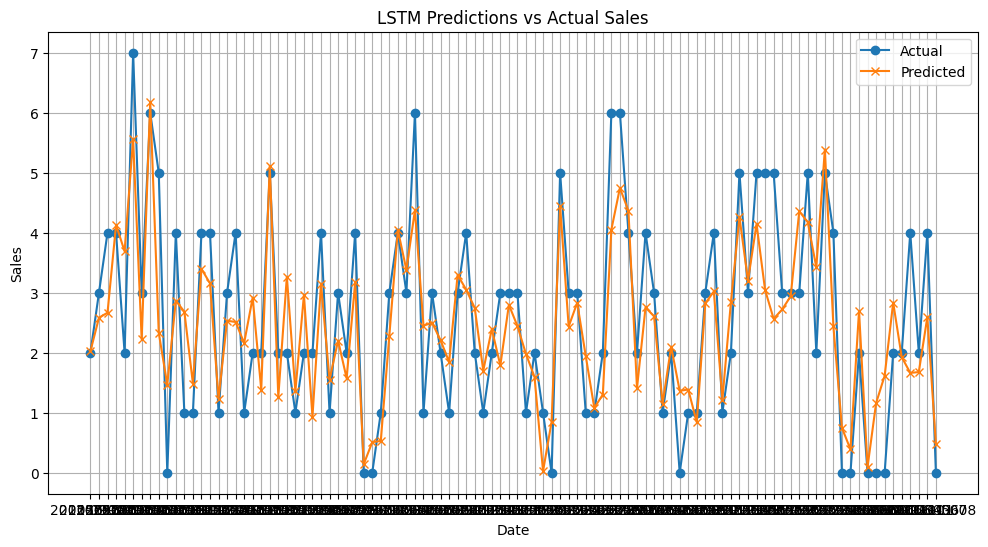

In [57]:
plot_lstm_predictions(key_to_populated_df[(1, 'BEAUTY')][1000:1100])

In [ ]:
def has_holiday(date_city_region, has_holiday_dict):
    date, city, region = date_city_region.split("_")
    return has_holiday_dict[date][city] or has_holiday_dict[date][region]
        

def process_xgb_data(data, has_holiday_dict, oil_prices_dict, stores_df):
    
    data = pd.merge(data, stores_df, how="left", on="store_nbr")

    data["date_city_region"] = data["date"] + "_" + data["city"] + "_" + data["state"]
    data["has_holiday"] = data["date_city_region"].apply(has_holiday(has_holiday_dict))

    data["oil_price"] = data["date"].map(oil_prices_dict)
    mean_oil_price = data["oil_price"].mean()
    data["oil_price"] = data["oil_price"].fillna(mean_oil_price)
    
    data["family"] = data["family"].astype("category")
    data["store_nbr"] = data["store_nbr"].astype("category")
    data["city"] = data["city"].astype("category")
    data["state"] = data["state"].astype("category")
    
    data = data.drop(columns=["id", "date", "date_city_region"])
    
    return data

In [6]:
has_holiday_dict = processed_holidays_events()
oil_prices_dict = process_oil_prices()
stores_df = process_stores_table()

XGBoost Classification Model

In [ ]:
model = XGBRegressor(
    n_estimators=250,
    max_depth=10,        
    learning_rate=0.05,  
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical = True
)

model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
y_pred = np.maximum(0, y_pred)
y_test = y_test.ravel()

rmsle = np.sqrt(mean_squared_error(np.log1p(y_test), np.log1p(y_pred)))
print(f"Root Mean Squared Error (RMSE): {rmsle:.4f}")

Root Mean Squared Error (RMSE): 1.3163
